In [12]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np
import json
import sys
sys.path.append(os.path.abspath("../../../")) 
from kingmaker_fork.likelihood_analysis.utils.performance_evaluation import fitting_score_components


scan_dir = "/data/user/fkrafft/csky_king_tests/binning_scan/"
paths = glob.glob("/data/user/fkrafft/csky_king_tests/binning_scan/*/summary.json")
fit_parameter_path = glob.glob("/data/user/fkrafft/csky_king_tests/binning_scan/*/fit_parameters.npz")

llh_csv_path = '/data/user/fkrafft/csky_king_tests/llh_score_summary.csv'


In [13]:

rows = []

for summary_path in glob.glob(f"{scan_dir}/*/summary.json"):
    with open(summary_path) as f:
        d = json.load(f)

    scan_path = os.path.dirname(summary_path)
    npz_path = os.path.join(scan_path, "fit_parameters.npz")

    avg_median_fit_qual = np.nan

    if os.path.exists(npz_path):
        with np.load(npz_path) as npz:
            fit_qual_all_gamma = npz["fit_quality"]

        medians = []

        for fit_quality_g in fit_qual_all_gamma:
            fq = np.asarray(fit_quality_g).ravel()
            fq = fq[np.isfinite(fq) & (fq > 0)]

            if len(fq) > 0:
                medians.append(np.median(fq))

        if len(medians) > 0:
            avg_median_fit_qual = np.mean(medians)

    rows.append({
        "id": d["id"],
        "status": d["status"],
        "runtime_sec": d["runtime_sec"],
        "minimum_counts": d["minimum_counts"],
        "sigma_bins": d["parametrization_bins"]["sigma"],
        "score": d["score"],
        "median_rms": d["median_rms"],
        "p90_rms": d["p90_rms"],
        "frac_skipped": d["frac_skipped"],
        "frac_failed": d["frac_failed"],
        "fit_npz": d["fit_npz"],
        "chi2": avg_median_fit_qual,
    })

df = pd.DataFrame(rows)
df = df[df["status"] == "done"].copy()
df = df.sort_values("score")

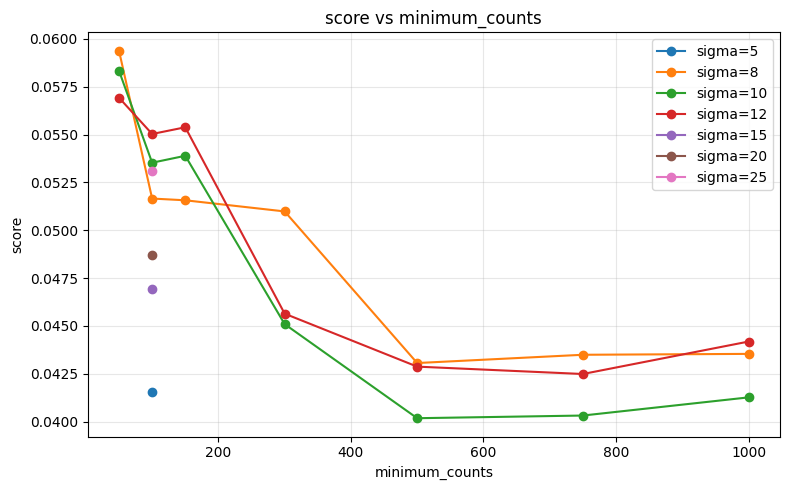

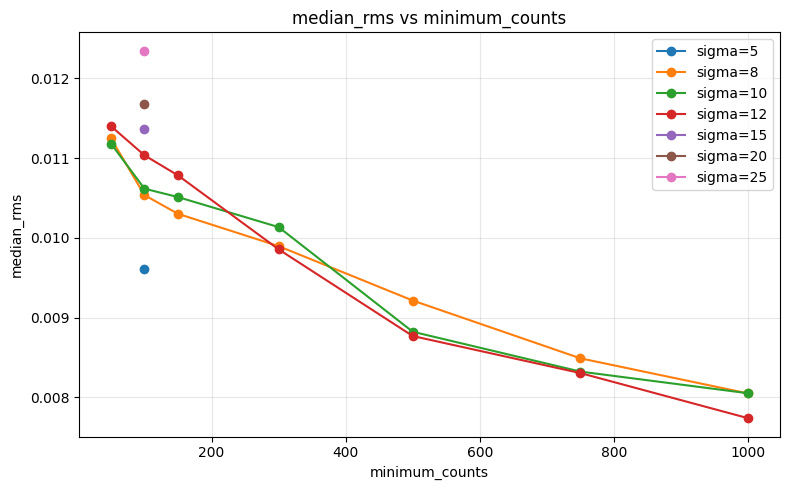

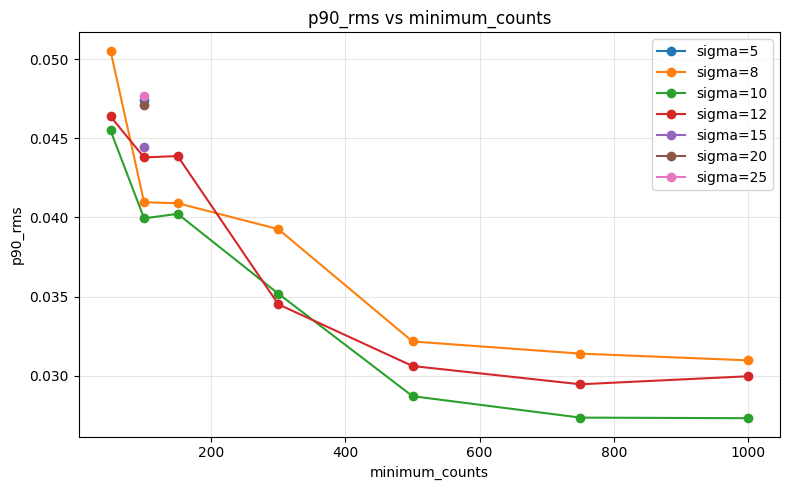

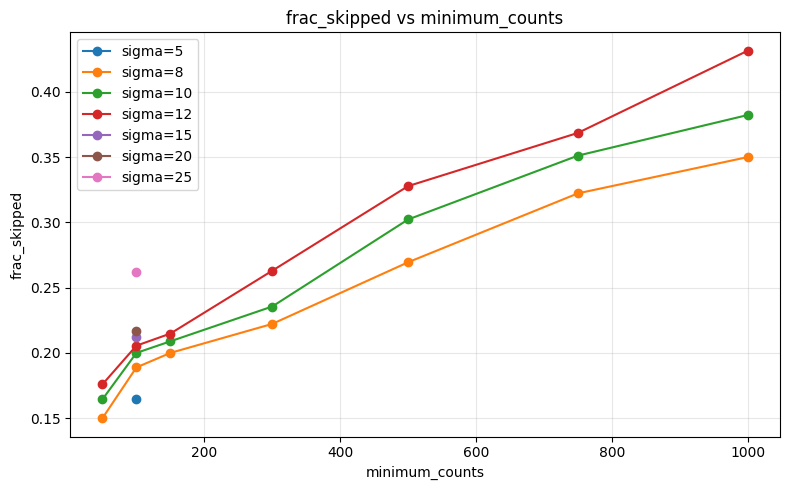

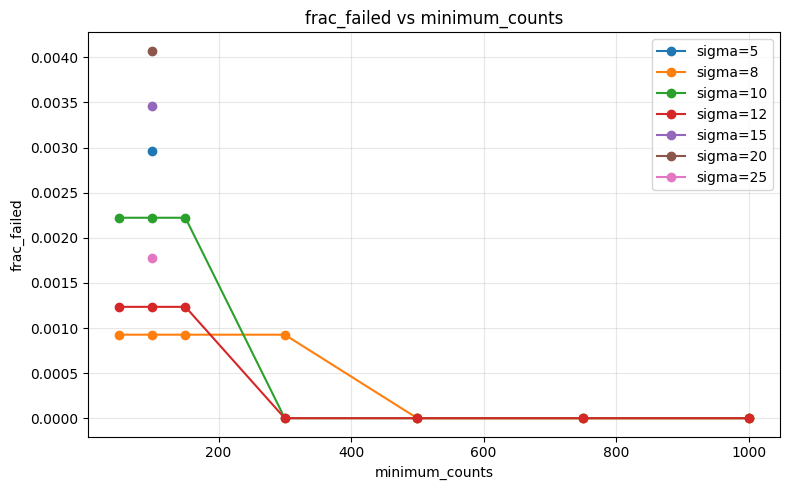

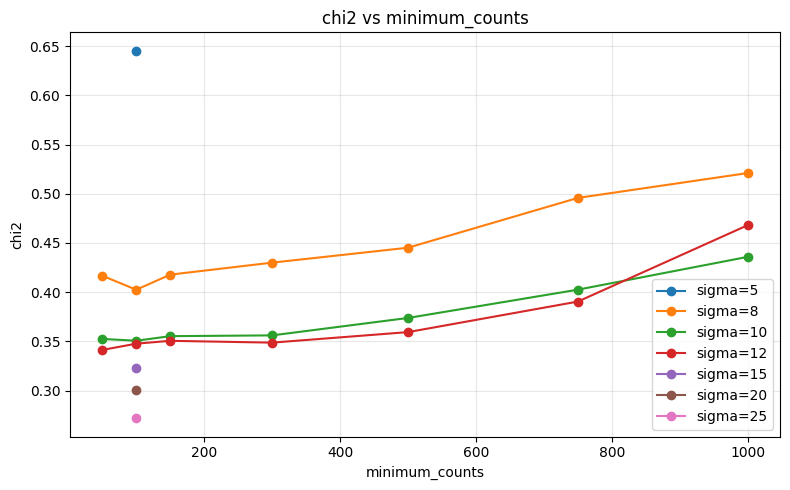

In [14]:
metrics = [
    "score",
    "median_rms",
    "p90_rms",
    "frac_skipped",
    "frac_failed",
    "chi2",
]

sigmas_to_plot = [5, 8, 10, 12, 15, 20, 25]

for metric in metrics:

    plt.figure(figsize=(8, 5))

    for sigma in sigmas_to_plot:

        sub = (
            df[df["sigma_bins"] == sigma]
            .sort_values("minimum_counts")
        )

        plt.plot(
            sub["minimum_counts"],
            sub[metric],
            marker="o",
            label=f"sigma={sigma}",
        )

    plt.xlabel("minimum_counts")
    plt.ylabel(metric)
    plt.title(f"{metric} vs minimum_counts")

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [15]:
df[df['sigma_bins'] == 12]

,id,status,runtime_sec,minimum_counts,sigma_bins,score,median_rms,p90_rms,frac_skipped,frac_failed,fit_npz,chi2
12,E6_D9_S12_MC750,done,742.204926,750,12,0.042483,0.008305,0.029458,0.368519,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.390481
23,E6_D9_S12_MC500,done,770.795045,500,12,0.042869,0.008769,0.030612,0.327778,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.359467
21,E6_D9_S12_MC1000,done,696.349781,1000,12,0.044178,0.007739,0.029965,0.431481,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.468083
20,E6_D9_S12_MC300,done,786.487778,300,12,0.045636,0.009856,0.034510,0.262963,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.348779
6,E6_D9_S12_MC100,done,849.932422,100,12,0.055029,0.011034,0.043786,0.205556,0.001235,/data/user/fkrafft/csky_king_tests/binning_sca...,0.347719
8,E6_D9_S12_MC150,done,854.501719,150,12,0.055380,0.010783,0.043874,0.214815,0.001235,/data/user/fkrafft/csky_king_tests/binning_sca...,0.350618
3,E6_D9_S12_MC50,done,876.875098,50,12,0.056926,0.011400,0.046374,0.175926,0.001235,/data/user/fkrafft/csky_king_tests/binning_sca...,0.341362


<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2127450/1184693787.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Fit quality score: $m_w = 0.3, \\alpha = 1, \\beta = 0.1, \mu = 2.0$")


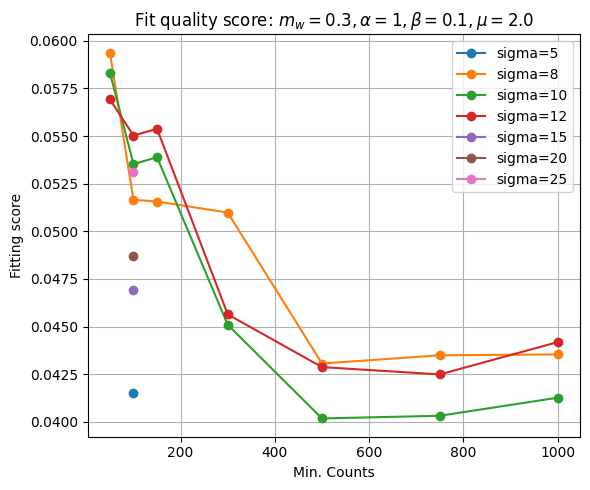

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

for sigma in sorted(df["sigma_bins"].unique()):

    sub = (
        df[df["sigma_bins"] == sigma]
        .sort_values("minimum_counts")
    )

    plt.plot(
        sub["minimum_counts"],
        sub["score"],
        marker="o",
        label=f"sigma={sigma}",
    )

plt.xlabel("Min. Counts")
plt.ylabel("Fitting score")
plt.title(f"Fit quality score: $m_w = 0.3, \\alpha = 1, \\beta = 0.1, \mu = 2.0$")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

### Compare to LLH scores (Total score)

In [17]:
df.columns

Index(['id', 'status', 'runtime_sec', 'minimum_counts', 'sigma_bins', 'score',
       'median_rms', 'p90_rms', 'frac_skipped', 'frac_failed', 'fit_npz',
       'chi2'],
      dtype='str')

In [18]:
llh_score_df = pd.read_csv(llh_csv_path)
llh_score_df.columns

Index(['min_counts', 'ang_err', 'llh_score'], dtype='str')

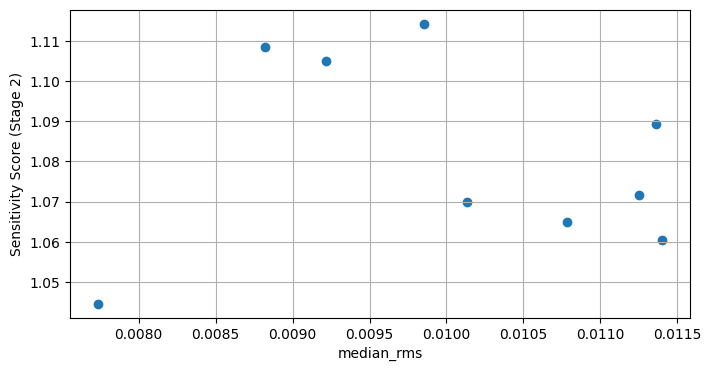

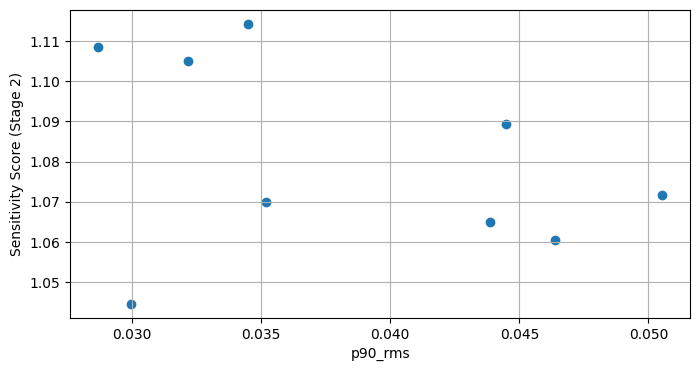

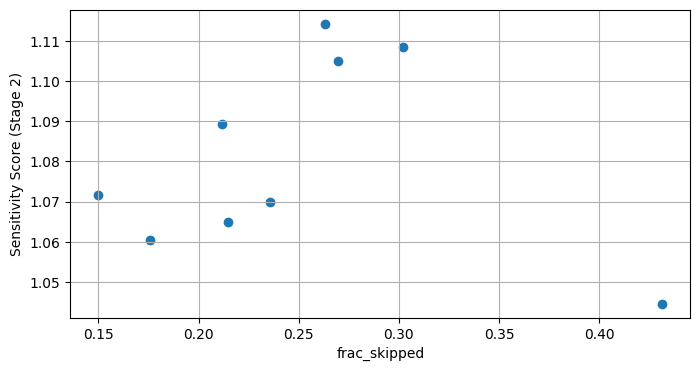

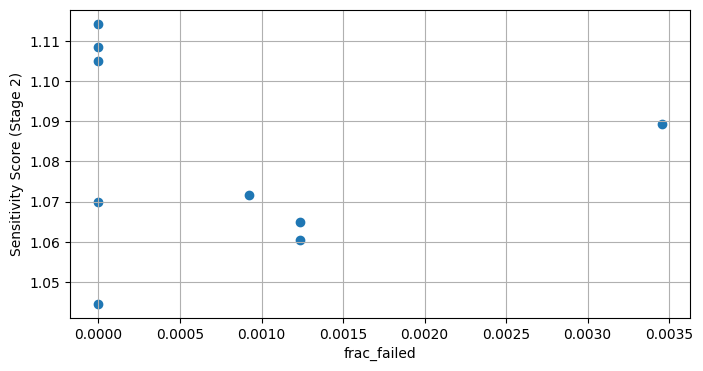

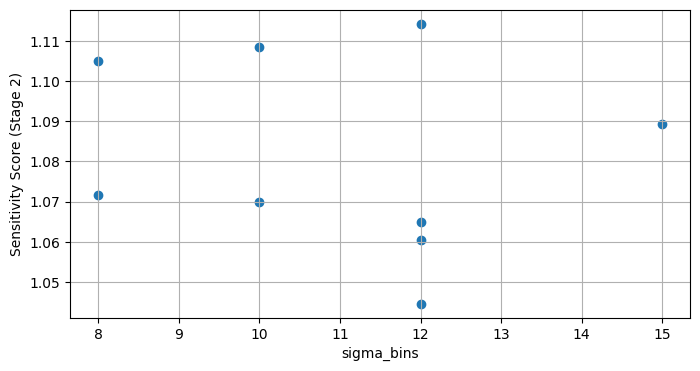

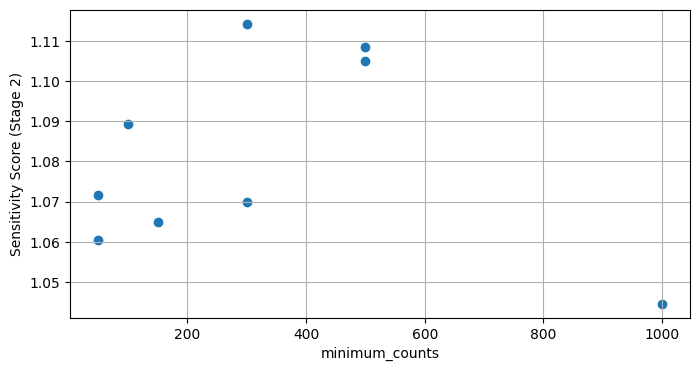

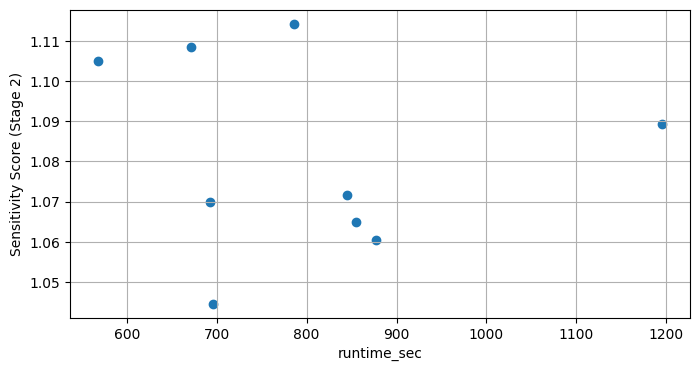

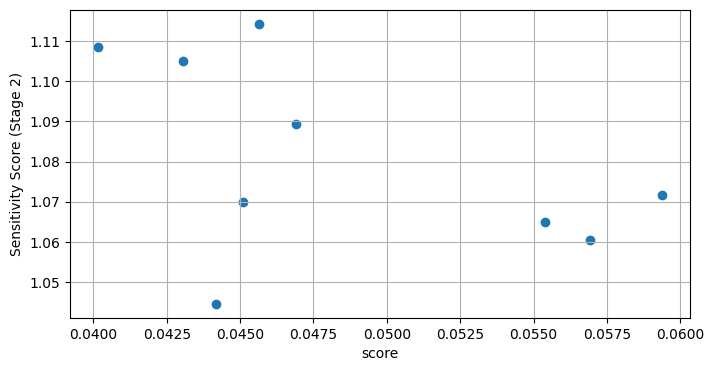

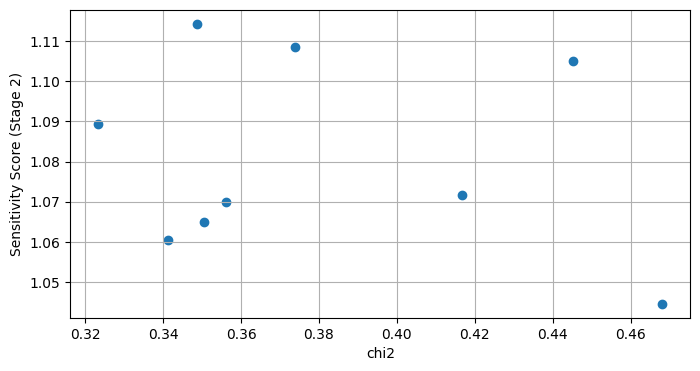

In [19]:
# Match:
# df["sigma_bins"]     <-> llh_score_df["ang_err"]
# df["minimum_counts"] <-> llh_score_df["min_counts"]

merged = df.merge(
    llh_score_df,
    left_on=["sigma_bins", "minimum_counts"],
    right_on=["ang_err", "min_counts"],
    how="inner"
)

# Optional: sort by x-axis
merged = merged.sort_values("llh_score")

y_cols = ["median_rms", "p90_rms", 'frac_skipped', 'frac_failed', 'sigma_bins', 'minimum_counts', 'runtime_sec', 'score', 'chi2']

for col in y_cols:
    plt.figure(figsize = (8, 4))
    plt.scatter( merged[col], merged["llh_score"])
    plt.ylabel("Sensitivity Score (Stage 2)")
    plt.xlabel(col)
    plt.grid(True)
    plt.show()

In [20]:
merged.sort_values('score')[['min_counts', 'ang_err', 'score', 'llh_score']].to_csv('score_summary_temporary.csv', sep = ';')

In [21]:
merged.sort_values('llh_score')

,id,status,runtime_sec,minimum_counts,sigma_bins,score,median_rms,p90_rms,frac_skipped,frac_failed,fit_npz,chi2,min_counts,ang_err,llh_score
2,E6_D9_S12_MC1000,done,696.349781,1000,12,0.044178,0.007739,0.029965,0.431481,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.468083,1000,12,1.044582
7,E6_D9_S12_MC50,done,876.875098,50,12,0.056926,0.011400,0.046374,0.175926,0.001235,/data/user/fkrafft/csky_king_tests/binning_sca...,0.341362,50,12,1.060443
6,E6_D9_S12_MC150,done,854.501719,150,12,0.055380,0.010783,0.043874,0.214815,0.001235,/data/user/fkrafft/csky_king_tests/binning_sca...,0.350618,150,12,1.064821
3,E6_D9_S10_MC300,done,692.732306,300,10,0.045090,0.010135,0.035181,0.235556,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.356147,300,10,1.069841
8,E6_D9_S08_MC50,done,844.851573,50,8,0.059382,0.011248,0.050526,0.150000,0.000926,/data/user/fkrafft/csky_king_tests/binning_sca...,0.416727,50,8,1.071567
5,E6_D9_S15_MC200,done,1195.269182,100,15,0.046905,0.011360,0.044473,0.211852,0.003457,/data/user/fkrafft/csky_king_tests/binning_sca...,0.323411,100,15,1.089415
1,E6_D9_S08_MC500,done,568.519452,500,8,0.043056,0.009214,0.032161,0.269444,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.445205,500,8,1.105038
0,E6_D9_S10_MC500,done,671.860527,500,10,0.040172,0.008823,0.028706,0.302222,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.373844,500,10,1.108464
4,E6_D9_S12_MC300,done,786.487778,300,12,0.045636,0.009856,0.034510,0.262963,0.000000,/data/user/fkrafft/csky_king_tests/binning_sca...,0.348779,300,12,1.114351


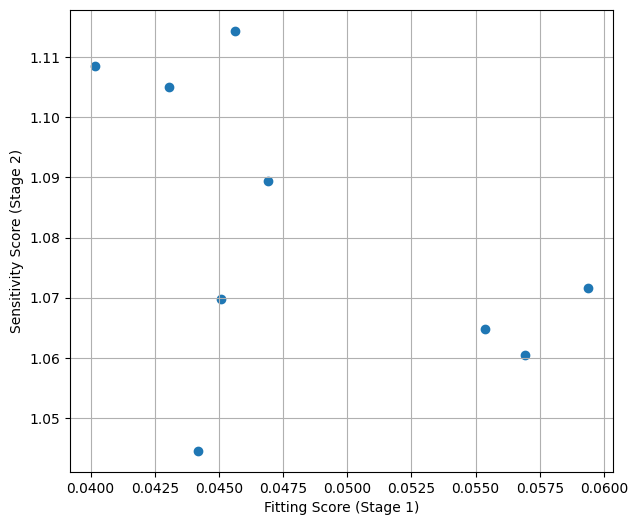

In [22]:
plt.figure(figsize= (7, 6))
plt.scatter( merged['score'], merged["llh_score"])
plt.ylabel("Sensitivity Score (Stage 2)")
plt.xlabel('Fitting Score (Stage 1)')
plt.grid(True)
plt.show()